In [ ]:
# !pip3 install pandas numpy matplotlib scipy

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm,lognorm

plt.rcParams["figure.figsize"] = (8,5)

In [82]:
trace = pd.read_csv("data-old/node_4_long_trace.csv")

trace.head()

,node_id,timestamp_usec,event,term,leader_id,value
0,4,85061357235,timeout,0,-1,0
1,4,85061357278,became_candidate,0,-1,0
2,4,85208816394,became_follower,2,0,0
3,4,85209053011,heartbeat,2,0,109552
4,4,85209342716,heartbeat,2,0,289712


In [83]:
trace = trace.sort_values("timestamp_usec").reset_index(drop=True)

# convert to seconds
trace["timestamp_sec"] = trace["timestamp_usec"] / 1e6

In [84]:
unstable_events = {
    "timeout",
    "became_candidate",
    "became_follower",
    "became_leader"
}

trace["unstable"] = trace["event"].isin(unstable_events)

In [85]:
WINDOW_SEC = 5

unstable_times = trace.loc[trace["unstable"], "timestamp_sec"].values

def near_unstable(t):
    return np.any(np.abs(unstable_times - t) < WINDOW_SEC)

heartbeats = trace[trace["event"] == "heartbeat"].copy()

heartbeats["near_unstable"] = heartbeats["timestamp_sec"].apply(near_unstable)

stable_heartbeats = heartbeats[~heartbeats["near_unstable"]].copy()

print("Total heartbeats:", len(heartbeats))
print("Stable heartbeats:", len(stable_heartbeats))

Total heartbeats: 104374
Stable heartbeats: 104339


In [86]:
stable_heartbeats["interval"] = stable_heartbeats["timestamp_sec"].diff()

intervals = stable_heartbeats["interval"].dropna()

intervals.describe()

count    104338.000000
mean          0.298143
std           0.469335
min           0.000079
25%           0.146504
50%           0.252754
75%           0.500340
max         138.422189
Name: interval, dtype: float64

In [87]:
# IQR-based outlier filtering
q1 = intervals.quantile(0.25)
q3 = intervals.quantile(0.75)
iqr = q3 - q1

lower_bound = 0.5
upper_bound = q3 + 1.5 * iqr

intervals = intervals[(intervals >= lower_bound) & (intervals <= upper_bound)]

print(f"Kept {len(intervals)} intervals after outlier filtering")
print(f"Bounds: [{lower_bound:.6f}, {upper_bound:.6f}]")

Kept 28302 intervals after outlier filtering
Bounds: [0.500000, 1.031094]


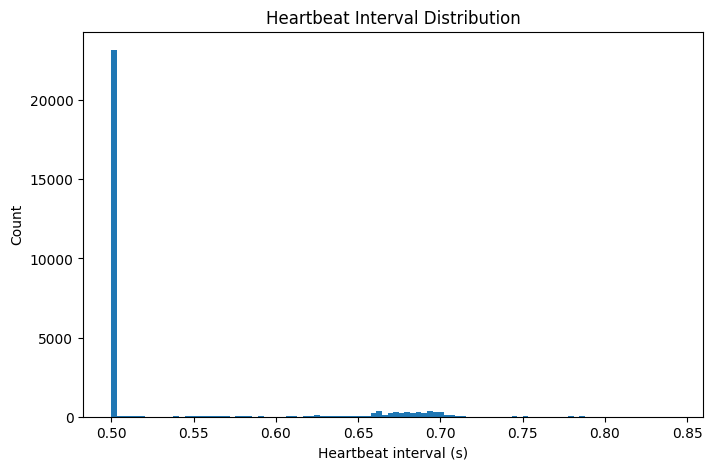

In [88]:
plt.hist(sorted(intervals), bins=100)
plt.xlabel("Heartbeat interval (s)")
plt.ylabel("Count")
plt.title("Heartbeat Interval Distribution")
plt.show()

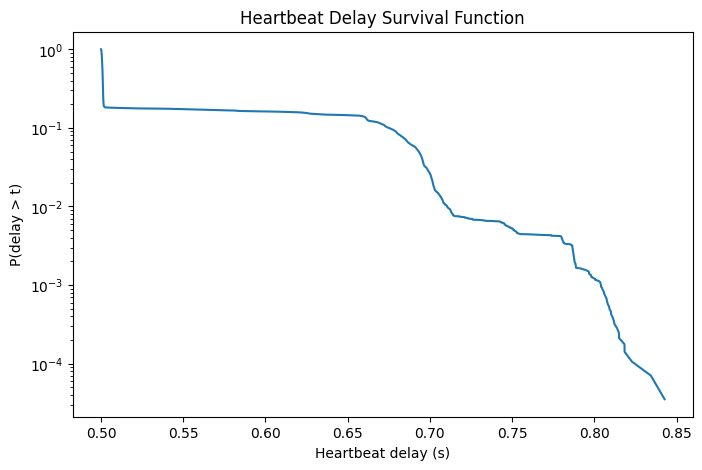

In [89]:
sorted_intervals = np.sort(intervals.values)

survival = 1.0 - np.arange(len(sorted_intervals)) / len(sorted_intervals)

plt.semilogy(sorted_intervals, survival)
plt.xlabel("Heartbeat delay (s)")
plt.ylabel("P(delay > t)")
plt.title("Heartbeat Delay Survival Function")
plt.show()

In [90]:
WINDOW_SIZE = 100
CHECK_INTERVAL = 0.1   # seconds
MIN_STD = 1e-3

In [91]:
def phi_normal(delay, window):
    
    mu = np.mean(window)
    sigma = max(np.std(window), MIN_STD)
    
    z = (delay - mu) / sigma
    
    prob = 1 - norm.cdf(z)
    
    prob = max(prob, 1e-12)
    
    return -np.log10(prob)

In [92]:
def phi_exponential(delay, window):
    
    mu = np.mean(window)
    
    prob = np.exp(-delay / mu)
    
    prob = max(prob, 1e-12)
    
    return -np.log10(prob)

In [120]:
def phi_lognormal(delay, window):

    window = np.array(window)

    # fit log-normal parameters
    shape, loc, scale = lognorm.fit(window, floc=0)

    prob = 1 - lognorm.cdf(delay, shape, loc, scale)

    prob = max(prob, 1e-12)

    return -np.log10(prob)

In [121]:
WINDOW = 100
MIN_STD = 1e-6

In [122]:
def t_phi_normal(window, phi_threshold):

    mu = np.mean(window)
    sigma = max(np.std(window), MIN_STD)

    target_prob = 10 ** (-phi_threshold)

    z = norm.ppf(1 - target_prob)

    return mu + sigma * z


def t_phi_exponential(window, phi_threshold):

    mu = np.mean(window)

    target_prob = 10 ** (-phi_threshold)

    return -mu * np.log(target_prob)

def t_phi_lognormal(window, phi_threshold):

    window = np.array(window)

    shape, loc, scale = lognorm.fit(window, floc=0)

    target_prob = 10 ** (-phi_threshold)

    return lognorm.ppf(1 - target_prob, shape, loc, scale)

In [123]:
window = list(intervals.values[:WINDOW])
times = times = trace["timestamp_sec"].values[1:]

phi_normal_series = []
phi_exp_series = []
phi_lognormal_series = []
time_series = []

for i in range(WINDOW, len(intervals)):

    delay = intervals.values[i]

    phi_n = phi_normal(delay, window)
    phi_e = phi_exponential(delay, window)
    phi_l = phi_lognormal(delay, window)

    phi_normal_series.append(phi_n)
    phi_exp_series.append(phi_e)
    phi_lognormal_series.append(phi_l)
    time_series.append(times[i])

    window.append(delay)
    window.pop(0)

phi_normal_series = np.array(phi_normal_series)
phi_exp_series = np.array(phi_exp_series)
phi_lognormal_series = np.array(phi_lognormal_series)
time_series = np.array(time_series)

In [125]:
phi_thresholds = range(1,10)

runtime_hours = (times[-1] - times[0]) / 3600

results = []

for thr in phi_thresholds:

    elections_normal = 0
    elections_exp = 0
    elections_logn = 0

    window = list(intervals[:WINDOW])

    for i in range(WINDOW, len(intervals)):

        Δ = intervals.values[i]

        t_n = t_phi_normal(window, thr)
        t_e = t_phi_exponential(window, thr)
        t_l = t_phi_lognormal(window, thr)

        if Δ > t_n:
            elections_normal += 1

        if Δ > t_e:
            elections_exp += 1

        if Δ > t_l:
            elections_logn += 1

        window.append(Δ)
        window.pop(0)

    results.append((
        thr,
        elections_normal / runtime_hours,
        elections_exp / runtime_hours,
        elections_logn / runtime_hours
    ))

results_df = pd.DataFrame(results,
    columns=[
        "phi",
        "normal_elections_per_hour",
        "exp_elections_per_hour",
        "lognormal_elections_per_hour"
    ])

results_df

,phi,normal_elections_per_hour,exp_elections_per_hour,lognormal_elections_per_hour
0,1,241.034962,0.0,239.653013
1,2,49.519844,0.0,48.253057
2,3,19.462450,0.0,18.425988
3,4,9.788806,0.0,9.212994
4,5,6.449096,0.0,6.333934
5,6,5.067147,0.0,4.951984
6,7,4.261010,0.0,4.261010
7,8,3.800360,0.0,3.685198
8,9,3.224548,0.0,3.224548


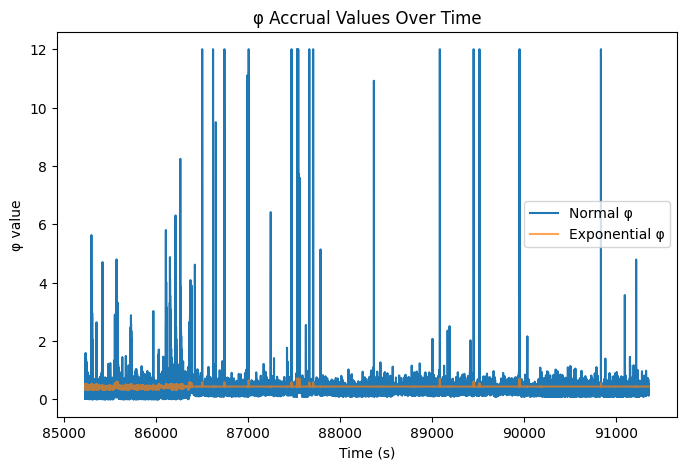

In [111]:
plt.plot(time_series, phi_normal_series, label="Normal φ")
plt.plot(time_series, phi_exp_series, label="Exponential φ", alpha=0.7)

plt.xlabel("Time (s)")
plt.ylabel("φ value")
plt.title("φ Accrual Values Over Time")

plt.legend()
plt.show()

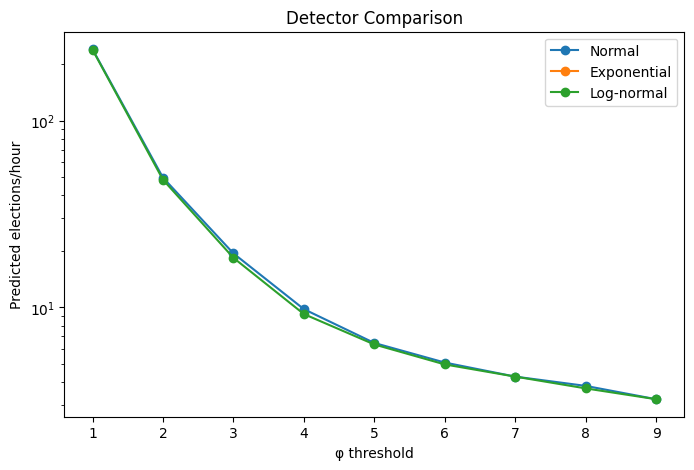

In [126]:
plt.plot(results_df["phi"], results_df["normal_elections_per_hour"], marker="o", label="Normal")
plt.plot(results_df["phi"], results_df["exp_elections_per_hour"], marker="o", label="Exponential")
plt.plot(results_df["phi"], results_df["lognormal_elections_per_hour"], marker="o", label="Log-normal")

plt.yscale("log")

plt.xlabel("φ threshold")
plt.ylabel("Predicted elections/hour")
plt.title("Detector Comparison")

plt.legend()
plt.show()

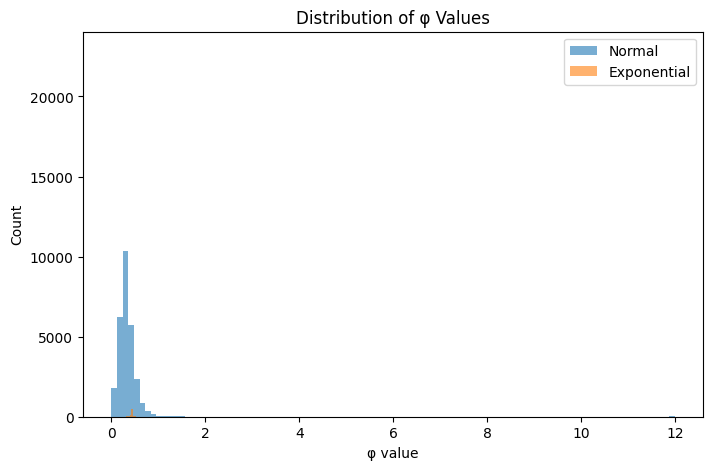

In [113]:
plt.hist(phi_normal_series, bins=100, alpha=0.6, label="Normal")
plt.hist(phi_exp_series, bins=100, alpha=0.6, label="Exponential")

plt.xlabel("φ value")
plt.ylabel("Count")
plt.title("Distribution of φ Values")

plt.legend()
plt.show()

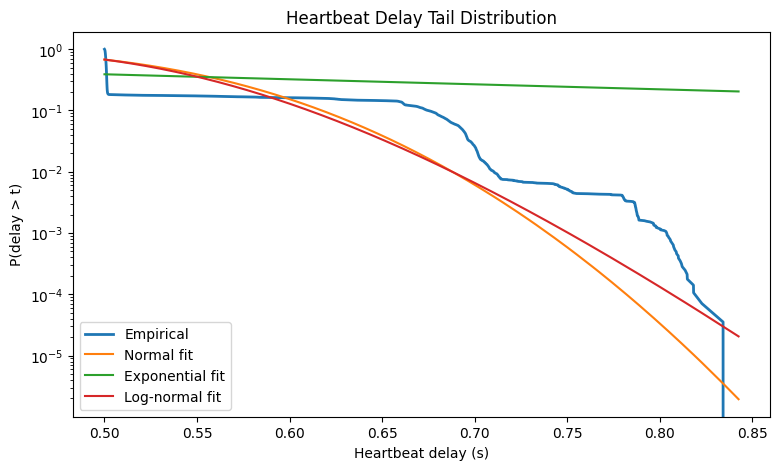

In [127]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, expon, lognorm

data = np.array(intervals.values)

# sort delays
x = np.sort(data)

# empirical survival function
survival_emp = 1 - np.arange(1, len(x)+1)/len(x)

# --- Fit distributions ---

# Normal
mu_n, sigma_n = norm.fit(data)

# Exponential
loc_e, scale_e = expon.fit(data, floc=0)

# Log-normal
shape_l, loc_l, scale_l = lognorm.fit(data, floc=0)

# --- Compute survival curves ---

survival_norm = 1 - norm.cdf(x, mu_n, sigma_n)
survival_exp = 1 - expon.cdf(x, loc_e, scale_e)
survival_logn = 1 - lognorm.cdf(x, shape_l, loc_l, scale_l)

# --- Plot ---
plt.figure(figsize=(9,5))

plt.plot(x, survival_emp, label="Empirical", linewidth=2)
plt.plot(x, survival_norm, label="Normal fit")
plt.plot(x, survival_exp, label="Exponential fit")
plt.plot(x, survival_logn, label="Log-normal fit")

plt.yscale("log")

plt.xlabel("Heartbeat delay (s)")
plt.ylabel("P(delay > t)")
plt.title("Heartbeat Delay Tail Distribution")

plt.legend()
plt.show()

In [131]:
runtime_hours = (times[-1] - times[0]) / 3600

T_values = [0.75, 1.0, 1.5, 2.0]  # seconds

TRIALS = 50

results_timeout = []

for T in T_values:

    total = 0

    for _ in range(TRIALS):

        elections = 0

        for Δ in intervals:

            τ = np.random.uniform(T, 2*T)

            if Δ > τ:
                elections += 1

        total += elections

    avg_elections = total / TRIALS
    elections_per_hour = avg_elections / runtime_hours

    results_timeout.append((T, elections_per_hour))

timeout_df = pd.DataFrame(results_timeout,
                          columns=["base_timeout_T",
                                   "elections_per_hour"])

timeout_df

,base_timeout_T,elections_per_hour
0,0.75,0.720917
1,1.00,0.000000
2,1.50,0.000000
3,2.00,0.000000


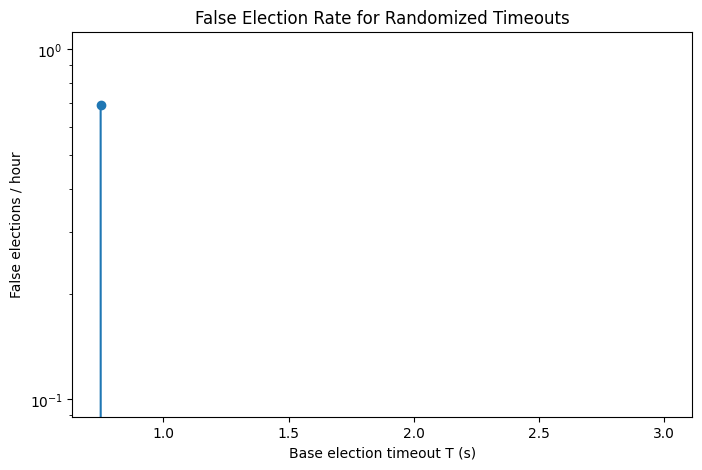

In [129]:
plt.plot(timeout_df["base_timeout_T"],
         timeout_df["elections_per_hour"],
         marker="o")

plt.yscale("log")

plt.xlabel("Base election timeout T (s)")
plt.ylabel("False elections / hour")
plt.title("False Election Rate for Randomized Timeouts")

plt.show()